# IoT Edge-Device Energy Prediction

Predicting how much energy (mJ) a solar/wind-powered IoT node consumes per cycle from its
operating state, so battery-constrained devices can budget power without extra metering
hardware.

Dataset: *IoT RL: Solar/Wind and Adaptive Transmission Control* (Kaggle, wisam1985),
20,000 rows. Target: `energy_consumed_mJ`.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Load the data

In [2]:
df = pd.read_csv('FINAL_IoT_RL_dataset_2026.csv')
print('Shape:', df.shape)
df.head()

Shape: (20000, 30)


,episode,step,episode_step,timestamp,battery_level,battery_voltage_V,solar_input_W,wind_input_W,cpu_usage,memory_usage,signal_quality,queue_size,temperature_C,humidity_pct,pressure_hPa,cloud_cover,action,action_name,reward,cumulative_ep_reward,next_battery,next_queue_size,energy_consumed_mJ,energy_harvested_mJ,net_energy_mJ,tx_success,packets_sent,latency_ms,packet_loss,done
0,1,1,1,2026-01-15 06:00:00,0.95363,4.1434,0.0444,1.0883,0.3984,0.3645,0.7000,12,9.53,63.71,1012.99,0.4308,3,TX_LOW,-0.479178,-0.47918,0.91731,10,656.511,2.781,-653.730,1,2,35.94,0,0
1,1,2,2,2026-01-15 06:00:30,0.91731,4.0873,0.0689,1.4709,0.5063,0.3750,0.7460,10,8.99,63.89,1012.72,0.4179,4,TX_MED,0.038881,-0.44030,0.87337,0,794.674,3.741,-790.934,1,10,23.41,0,0
2,1,3,3,2026-01-15 06:01:00,0.87337,4.0451,0.0681,1.4726,0.6672,0.4266,0.7435,0,9.77,65.17,1012.59,0.4249,5,TX_HIGH,-1.446039,-1.88634,0.80496,1,1235.482,4.074,-1231.408,0,0,0.00,0,0
3,1,4,4,2026-01-15 06:01:30,0.80496,3.9585,0.0662,1.1491,0.0550,0.1125,0.8003,1,7.09,61.23,1012.46,0.4046,1,SLEEP_LIGHT,-0.029067,-1.91540,0.79995,3,93.437,3.284,-90.153,0,0,0.00,0,0
4,1,5,5,2026-01-15 06:02:00,0.79995,3.9548,0.0000,1.4552,0.0556,0.2114,0.7698,3,7.38,53.67,1012.37,0.3894,1,SLEEP_LIGHT,-0.058895,-1.97430,0.79521,6,88.536,3.117,-85.419,0,0,0.00,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   episode               20000 non-null  int64  
 1   step                  20000 non-null  int64  
 2   episode_step          20000 non-null  int64  
 3   timestamp             20000 non-null  str    
 4   battery_level         20000 non-null  float64
 5   battery_voltage_V     20000 non-null  float64
 6   solar_input_W         20000 non-null  float64
 7   wind_input_W          20000 non-null  float64
 8   cpu_usage             20000 non-null  float64
 9   memory_usage          20000 non-null  float64
 10  signal_quality        20000 non-null  float64
 11  queue_size            20000 non-null  int64  
 12  temperature_C         20000 non-null  float64
 13  humidity_pct          20000 non-null  float64
 14  pressure_hPa          20000 non-null  float64
 15  cloud_cover           20000 no

In [4]:
df.describe()

,episode,step,episode_step,battery_level,battery_voltage_V,solar_input_W,wind_input_W,cpu_usage,memory_usage,signal_quality,queue_size,temperature_C,humidity_pct,pressure_hPa,cloud_cover,action,reward,cumulative_ep_reward,next_battery,next_queue_size,energy_consumed_mJ,energy_harvested_mJ,net_energy_mJ,tx_success,packets_sent,latency_ms,packet_loss,done
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,244.926500,10000.500000,24.44450,0.317889,3.381453,1.142846,0.781507,0.282045,0.352050,0.656476,26.311150,5.487162,61.675589,1010.885466,0.416778,1.717000,-0.809736,-13.103896,0.298479,25.990950,360.457926,11.751451,-348.706478,0.260550,1.499200,8.269709,0.12495,0.022950
std,130.195394,5773.647028,16.18593,0.266006,0.319366,1.365030,0.566760,0.209268,0.148816,0.166437,21.636969,4.215536,11.327967,7.187045,0.264690,1.552492,0.858885,14.322787,0.257223,21.886352,353.852312,11.653959,353.367350,0.438946,3.080791,15.531673,0.33067,0.149748
min,1.000000,1.000000,1.00000,0.020010,3.000900,0.000000,0.000000,0.010000,0.050000,0.050000,0.000000,-2.520000,32.530000,993.530000,0.000000,0.000000,-3.000000,-147.305770,0.000000,0.000000,31.162000,0.000000,-1459.430000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,136.000000,5000.750000,11.00000,0.062647,3.076275,0.002300,0.323075,0.110500,0.232000,0.546500,8.000000,1.560000,52.770000,1005.640000,0.197400,0.000000,-1.061170,-15.366585,0.058472,8.000000,40.628750,2.047000,-668.009250,0.000000,0.000000,0.000000,0.00000,0.000000
50%,253.000000,10000.500000,22.00000,0.255720,3.307300,0.460350,0.692750,0.216500,0.343000,0.659700,18.000000,5.480000,60.530000,1011.690000,0.382200,1.000000,-0.431509,-8.866880,0.232235,18.000000,94.330500,6.314000,-91.629500,0.000000,0.000000,0.000000,0.00000,0.000000
75%,358.000000,15000.250000,35.00000,0.535013,3.642100,2.197150,1.167275,0.402000,0.449600,0.772100,50.000000,9.450000,70.002500,1016.520000,0.618525,3.000000,-0.194554,-4.606043,0.504330,50.000000,677.883750,20.606000,-35.847500,1.000000,2.000000,11.242500,0.00000,0.000000
max,459.000000,20000.000000,109.00000,0.979460,4.185100,5.122900,2.984500,0.990000,0.868400,0.960000,60.000000,14.680000,99.000000,1028.330000,1.000000,5.000000,0.409549,0.451740,0.973290,60.000000,1465.042000,45.780000,8.388000,1.000000,20.000000,95.630000,1.00000,1.000000


## Cleaning

In [5]:
# check the three things that would break a regression
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Negative energy:', (df['energy_consumed_mJ'] < 0).sum())

Missing values: 0
Duplicate rows: 0
Negative energy: 0


Data is clean, so no rows need dropping.

## Feature selection

Some columns are computed from the target and would leak the answer, so they're excluded.
`net_energy_mJ = harvested - consumed` correlates -0.999 with the target; `energy_harvested_mJ`,
`next_*`, `reward`, `cumulative_ep_reward` and `done` are outcomes a live device wouldn't
know yet. We keep six features describing the device's current state.

In [6]:
TARGET = 'energy_consumed_mJ'
FEATURES = ['cpu_usage', 'memory_usage', 'signal_quality',
            'action', 'queue_size', 'temperature_C']

X = df[FEATURES].copy()
y = df[TARGET].copy()
X.shape

(20000, 6)

## Visualizations

### Correlation heatmap

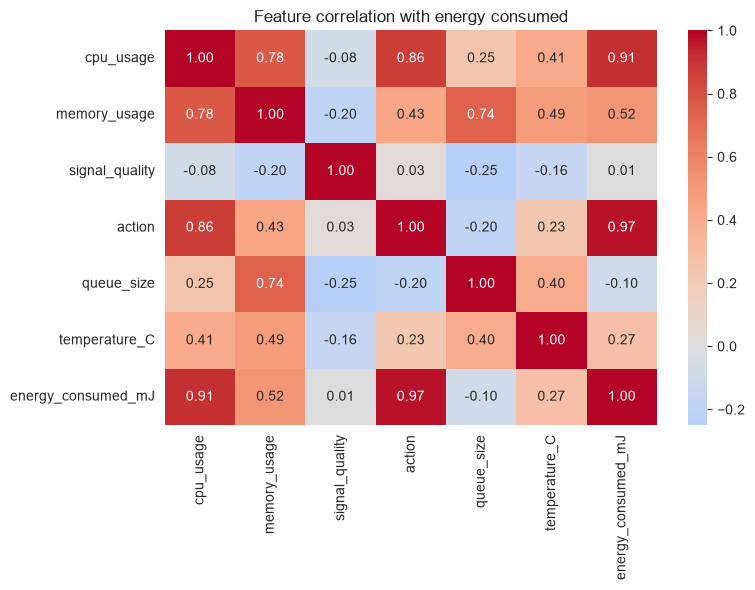

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Feature correlation with energy consumed')
plt.tight_layout()
plt.show()

`action` and `cpu_usage` correlate most strongly with energy — the power mode and compute load drive consumption.

### Energy distribution and energy by action

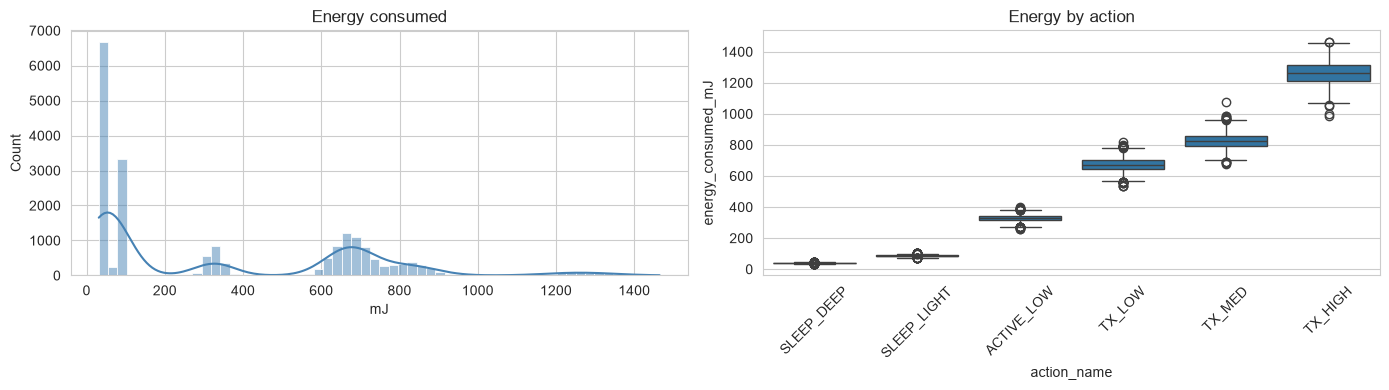

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Energy consumed'); ax[0].set_xlabel('mJ')

sns.boxplot(x='action_name', y=TARGET, data=df, ax=ax[1],
            order=['SLEEP_DEEP','SLEEP_LIGHT','ACTIVE_LOW','TX_LOW','TX_MED','TX_HIGH'])
ax[1].set_title('Energy by action'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Energy is multi-modal: sleep modes use little, transmission modes (TX_LOW→TX_HIGH) use progressively more.

### CPU usage vs energy

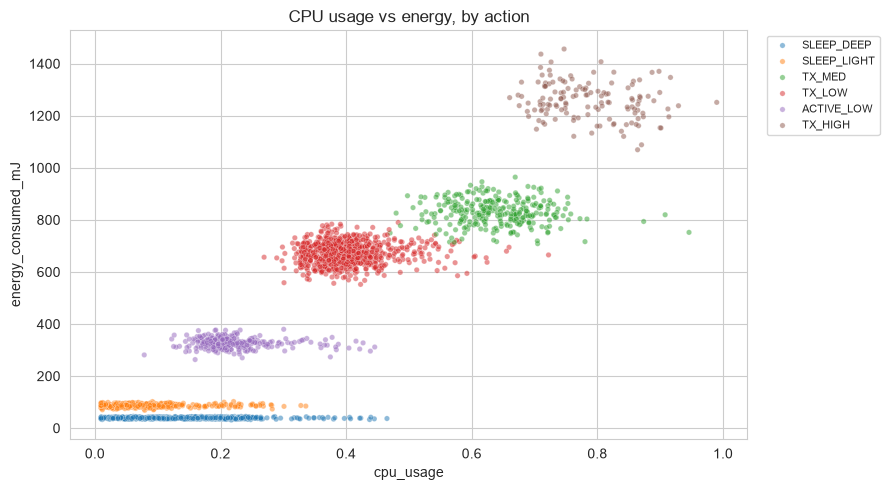

In [9]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='cpu_usage', y=TARGET, hue='action_name',
                data=df.sample(3000, random_state=42), alpha=0.5, s=15)
plt.title('CPU usage vs energy, by action')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Energy rises with CPU within each mode, but the action sets the baseline — this action x CPU interaction is why tree models beat a straight line.

## Split and standardize

In [10]:
feature_columns = FEATURES
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit scaler on train only, then reuse on test (saved for the API)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train_s.shape, X_test_s.shape)

(16000, 6) (4000, 6)


## Train and compare four models

Two linear implementations (SGD and OLS) against a decision tree and a random forest.

In [11]:
results = {}

# linear #1 - stochastic gradient descent
sgd = SGDRegressor(max_iter=1000, penalty='l2', eta0=0.01,
                   learning_rate='invscaling', random_state=42)
sgd.fit(X_train_s, y_train)
p = sgd.predict(X_test_s)
results['Linear (SGD)'] = {'model': sgd, 'MSE': mean_squared_error(y_test, p), 'R2': r2_score(y_test, p)}

# linear #2 - ordinary least squares
ols = LinearRegression()
ols.fit(X_train_s, y_train)
p = ols.predict(X_test_s)
results['Linear (OLS)'] = {'model': ols, 'MSE': mean_squared_error(y_test, p), 'R2': r2_score(y_test, p)}

# tree
dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
dt.fit(X_train_s, y_train)
p = dt.predict(X_test_s)
results['Decision Tree'] = {'model': dt, 'MSE': mean_squared_error(y_test, p), 'R2': r2_score(y_test, p)}

# ensemble
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
p = rf.predict(X_test_s)
results['Random Forest'] = {'model': rf, 'MSE': mean_squared_error(y_test, p), 'R2': r2_score(y_test, p)}

pd.DataFrame({k: {'MSE': v['MSE'], 'RMSE': v['MSE']**0.5, 'R2': v['R2']}
              for k, v in results.items()}).T

,MSE,RMSE,R2
Linear (SGD),4377.316138,66.161289,0.966297
Linear (OLS),4355.253046,65.994341,0.966467
Decision Tree,1049.577411,32.397182,0.991919
Random Forest,959.744890,30.979750,0.992610


Both linear models score about the same (same linear form, different solver). Random Forest has the lowest error. **Best model = lowest test RMSE**, since RMSE is in the target's units (mJ) and is measured on unseen test data.

## Loss curve (train vs test)

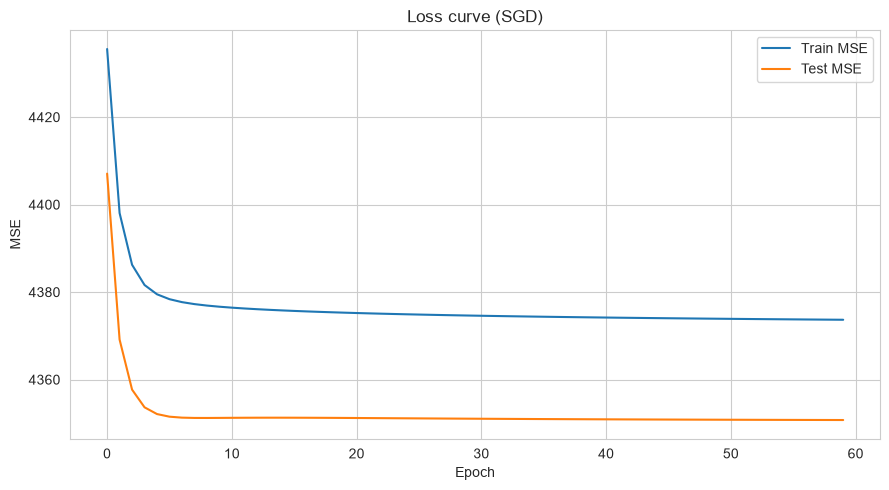

In [12]:
# retrain SGD epoch by epoch to watch convergence
lc = SGDRegressor(max_iter=1, warm_start=True, penalty='l2', eta0=0.01,
                  learning_rate='invscaling', random_state=42, tol=None)
train_loss, test_loss = [], []
for _ in range(60):
    lc.partial_fit(X_train_s, y_train)
    train_loss.append(mean_squared_error(y_train, lc.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, lc.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label='Train MSE')
plt.plot(test_loss, label='Test MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Loss curve (SGD)')
plt.legend(); plt.tight_layout(); plt.show()

Train and test loss fall together with no gap — the linear model isn't overfitting.

## Scatter with fitted line

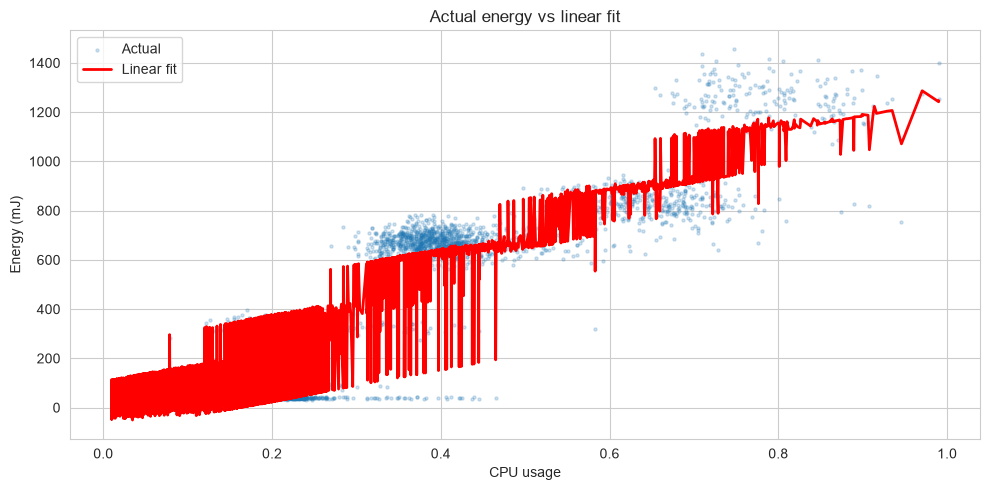

In [13]:
order = np.argsort(X_test['cpu_usage'].values)
cpu = X_test['cpu_usage'].values[order]
actual = y_test.values[order]
line = sgd.predict(X_test_s)[order]

plt.figure(figsize=(10, 5))
plt.scatter(cpu, actual, s=5, alpha=0.2, label='Actual')
plt.plot(cpu, line, color='red', linewidth=2, label='Linear fit')
plt.xlabel('CPU usage'); plt.ylabel('Energy (mJ)')
plt.title('Actual energy vs linear fit')
plt.legend(); plt.tight_layout(); plt.show()

The line tracks the upward trend; the spread at each CPU level is the different action modes, which the trees resolve better.

## Save the best model

In [14]:
best_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_name]['model']
print('Best model:', best_name, '| RMSE =', round(results[best_name]['MSE']**0.5, 2))

joblib.dump(best_model, 'best_model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

Best model: Random Forest | RMSE = 30.98


['feature_columns.pkl']

## Single-row prediction (used by the API)

In [15]:
def predict_single(row_df, model, scaler, feature_columns):
    row = row_df[feature_columns]
    return float(model.predict(scaler.transform(row))[0])

sample = X_test.iloc[[0]]
print('Predicted:', round(predict_single(sample, best_model, scaler, feature_columns), 2), 'mJ')
print('Actual:   ', round(float(y_test.iloc[0]), 2), 'mJ')

Predicted: 39.76 mJ
Actual:    35.58 mJ


## Notes for the demo

- Loss is low (RF RMSE ≈ 31 mJ on a target ranging 31–1465). To reduce it further, add
  richer features (battery state, radio conditions) rather than more tuning.
- Hyperparameters: SGD `eta0`/`penalty`/`max_iter`; RF `n_estimators`/`max_depth`/
  `min_samples_leaf`; tree `max_depth`. Tune with GridSearchCV.
- New data: the API `/retrain` endpoint refits the model on an uploaded CSV and swaps it
  in.